In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

pd.set_option("display.max_columns", None)

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")

sns.set_palette("Set2")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#333333",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "grid.color": "#dddddd",
    "grid.linestyle": "--",
    "font.size": 10,
    "figure.dpi": 100
})

In [4]:
def plot_2x2(plot_funcs, titles, suptitle=None, figsize=(14, 10), save_path=None):
    """
    plot_funcs: list of 4 functions, each taking an ax and drawing on it
    titles: list of 4 subplot titles
    suptitle: optional overall figure title
    save_path: optional path to save the figure (e.g. '../reports/figures/eda_grid1.png')
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()

    for ax, func, title in zip(axes, plot_funcs, titles):
        func(ax)
        ax.set_title(title, pad=10)

    if suptitle:
        fig.suptitle(suptitle, fontsize=15, fontweight="bold", y=1.02)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)

    plt.show()

In [5]:

df = pd.read_csv("/run/media/awongo-fahadi-rashid/AFRAH/Projects/Recess Term/Finance/data/raw/credit_scoring_sample.csv")

# Drop stray index column if present (common in this dataset)
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.shape)
df.head()


(45063, 8)


,SeriousDlqin2yrs,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,MonthlyIncome,NumberOfDependents
0,0,64,0,0.249908,0,0,8158.0,0.0
1,0,58,0,3870.000000,0,0,NaN,0.0
2,0,41,0,0.456127,0,0,6666.0,0.0
3,0,43,0,0.000190,0,0,10500.0,2.0
4,1,49,0,0.271820,0,0,400.0,0.0


In [6]:
# Keep df_raw as the untouched original import
df_raw = df.copy()

# df is now your working copy — all cleaning happens here
df = df_raw.copy()

In [7]:
df.isnull().sum()

SeriousDlqin2yrs                           0
age                                        0
NumberOfTime30-59DaysPastDueNotWorse       0
DebtRatio                                  0
NumberOfTimes90DaysLate                    0
NumberOfTime60-89DaysPastDueNotWorse       0
MonthlyIncome                           8643
NumberOfDependents                      1117
dtype: int64

In [8]:
print("MonthlyIncome missing %:", (8643 / len(df)) * 100)
print("NumberOfDependents missing %:", (1117 / len(df)) * 100)

MonthlyIncome missing %: 19.17981492577059
NumberOfDependents missing %: 2.4787519694649713


In [9]:
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(df["NumberOfDependents"].mode()[0])

df["NumberOfDependents"] = df["NumberOfDependents"].astype(int)

In [10]:
print(df.isnull().sum())
print(df["NumberOfDependents"].dtype)

SeriousDlqin2yrs                        0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
NumberOfTimes90DaysLate                 0
NumberOfTime60-89DaysPastDueNotWorse    0
MonthlyIncome                           0
NumberOfDependents                      0
dtype: int64
int64


In [11]:
print(df["DebtRatio"].describe())
print("\nValues above 10:", (df["DebtRatio"] > 10).sum())
print("Values above 1000:", (df["DebtRatio"] > 1000).sum())

count     45063.000000
mean        352.062688
std        2467.556358
min           0.000000
25%           0.176373
50%           0.373949
75%           0.857027
max      326442.000000
Name: DebtRatio, dtype: float64

Values above 10: 8434
Values above 1000: 4859


In [12]:
extreme = df[df["DebtRatio"] > 1000][["MonthlyIncome", "DebtRatio"]]
print(extreme.describe())
extreme.head(10)

       MonthlyIncome      DebtRatio
count    4859.000000    4859.000000
mean     4841.742128    3010.938465
std      1253.088711    6957.428217
min         0.000000    1001.000000
25%      5166.000000    1593.000000
50%      5166.000000    2311.000000
75%      5166.000000    3387.000000
max      5166.000000  326442.000000


,MonthlyIncome,DebtRatio
1,5166.0,3870.0
15,5166.0,1328.0
25,5166.0,1296.0
29,5166.0,3252.0
30,5166.0,1421.0
31,5166.0,1513.0
35,5166.0,5089.0
37,5166.0,2078.0
42,5166.0,1419.0
63,5166.0,3082.0


In [13]:
df["DebtRatio_Flag"] = (df["DebtRatio"] > 10).astype(int)
print(df["DebtRatio_Flag"].value_counts())

DebtRatio_Flag
0    36629
1     8434
Name: count, dtype: int64


In [14]:
upper_cap = df["DebtRatio"].quantile(0.975)  # 97.5th percentile
print("Capping DebtRatio at:", upper_cap)

df["DebtRatio"] = np.where(df["DebtRatio"] > upper_cap, upper_cap, df["DebtRatio"])

Capping DebtRatio at: 3496.0


In [15]:
income_cap = df["MonthlyIncome"].quantile(0.975)
print("Capping MonthlyIncome at:", income_cap)

df["MonthlyIncome"] = np.where(df["MonthlyIncome"] > income_cap, income_cap, df["MonthlyIncome"])

df["MonthlyIncome"].describe()

Capping MonthlyIncome at: 16529.599999999977


count    45063.000000
mean      5860.722637
std       3425.638874
min          0.000000
25%       3721.000000
50%       5166.000000
75%       7121.500000
max      16529.600000
Name: MonthlyIncome, dtype: float64

/tmp/ipykernel_138502/2834596562.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  lambda ax: sns.countplot(x="SeriousDlqin2yrs", data=df, ax=ax, palette="Set2"),


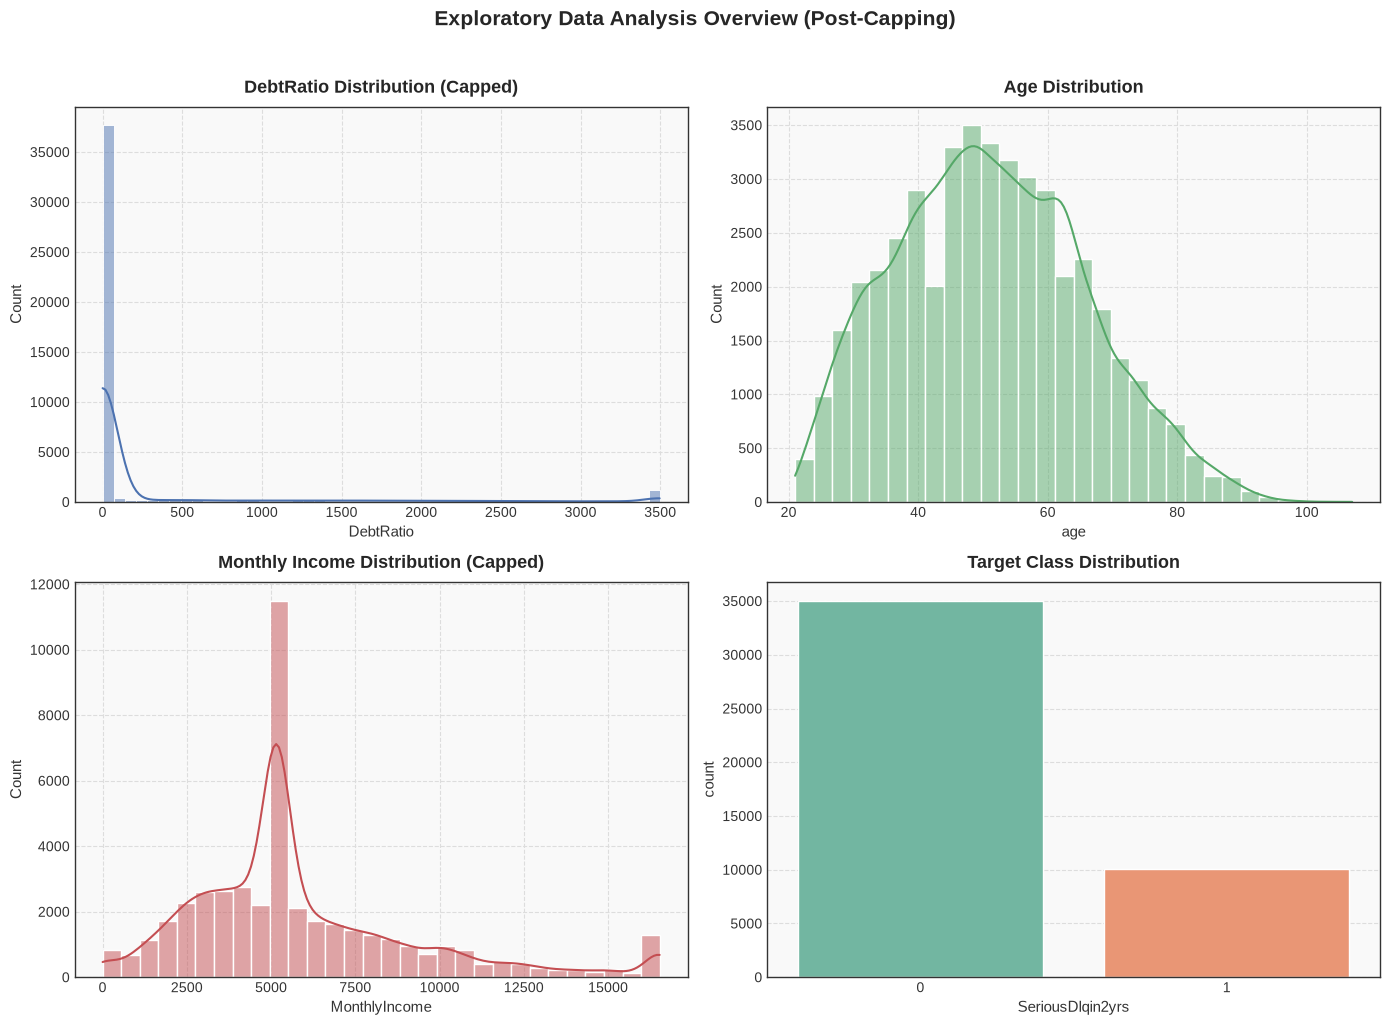

In [16]:
plot_2x2(
    plot_funcs=[
        lambda ax: sns.histplot(df["DebtRatio"], bins=50, kde=True, ax=ax, color="#4C72B0"),
        lambda ax: sns.histplot(df["age"], bins=30, kde=True, ax=ax, color="#55A868"),
        lambda ax: sns.histplot(df["MonthlyIncome"], bins=30, kde=True, ax=ax, color="#C44E52"),
        lambda ax: sns.countplot(x="SeriousDlqin2yrs", data=df, ax=ax, palette="Set2"),
    ],
    titles=[
        "DebtRatio Distribution (Capped)",
        "Age Distribution",
        "Monthly Income Distribution (Capped)",
        "Target Class Distribution"
    ],
    suptitle="Exploratory Data Analysis Overview (Post-Capping)",
    save_path="../reports/figures/eda_overview_v2.png"
)

In [17]:
# Total past-due incidents combined
df["TotalPastDue"] = (
    df["NumberOfTime30-59DaysPastDueNotWorse"] +
    df["NumberOfTime60-89DaysPastDueNotWorse"] +
    df["NumberOfTimes90DaysLate"]
)

# Income per dependent (avoid divide by zero)
df["IncomePerDependent"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)

# Age bracket / life stage
df["AgeGroup"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
)

# High debt burden flag (median split)
df["HighDebtRatio"] = (df["DebtRatio"] > df["DebtRatio"].median()).astype(int)

# Log-transformed DebtRatio (helps linear models handle skew)
df["DebtRatio_log"] = np.log1p(df["DebtRatio"])

# Any late payment at all (binary signal, often more predictive than raw counts)
df["HasAnyLatePayment"] = (df["TotalPastDue"] > 0).astype(int)

df.head()

,SeriousDlqin2yrs,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,MonthlyIncome,NumberOfDependents,DebtRatio_Flag,TotalPastDue,IncomePerDependent,AgeGroup,HighDebtRatio,DebtRatio_log,HasAnyLatePayment
0,0,64,0,0.249908,0,0,8158.0,0,0,0,8158.0,55-64,0,0.223070,0
1,0,58,0,3496.000000,0,0,5166.0,0,1,0,5166.0,55-64,1,8.159661,0
2,0,41,0,0.456127,0,0,6666.0,0,0,0,6666.0,35-44,1,0.375780,0
3,0,43,0,0.000190,0,0,10500.0,2,0,0,3500.0,35-44,0,0.000190,0
4,1,49,0,0.271820,0,0,400.0,0,0,0,400.0,45-54,0,0.240449,0


/tmp/ipykernel_138502/2100915074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  lambda ax: sns.boxplot(x="SeriousDlqin2yrs", y="TotalPastDue", data=df, ax=ax, palette="Set2"),
/tmp/ipykernel_138502/2100915074.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  lambda ax: sns.boxplot(x="SeriousDlqin2yrs", y="IncomePerDependent", data=df, ax=ax, palette="Set2"),


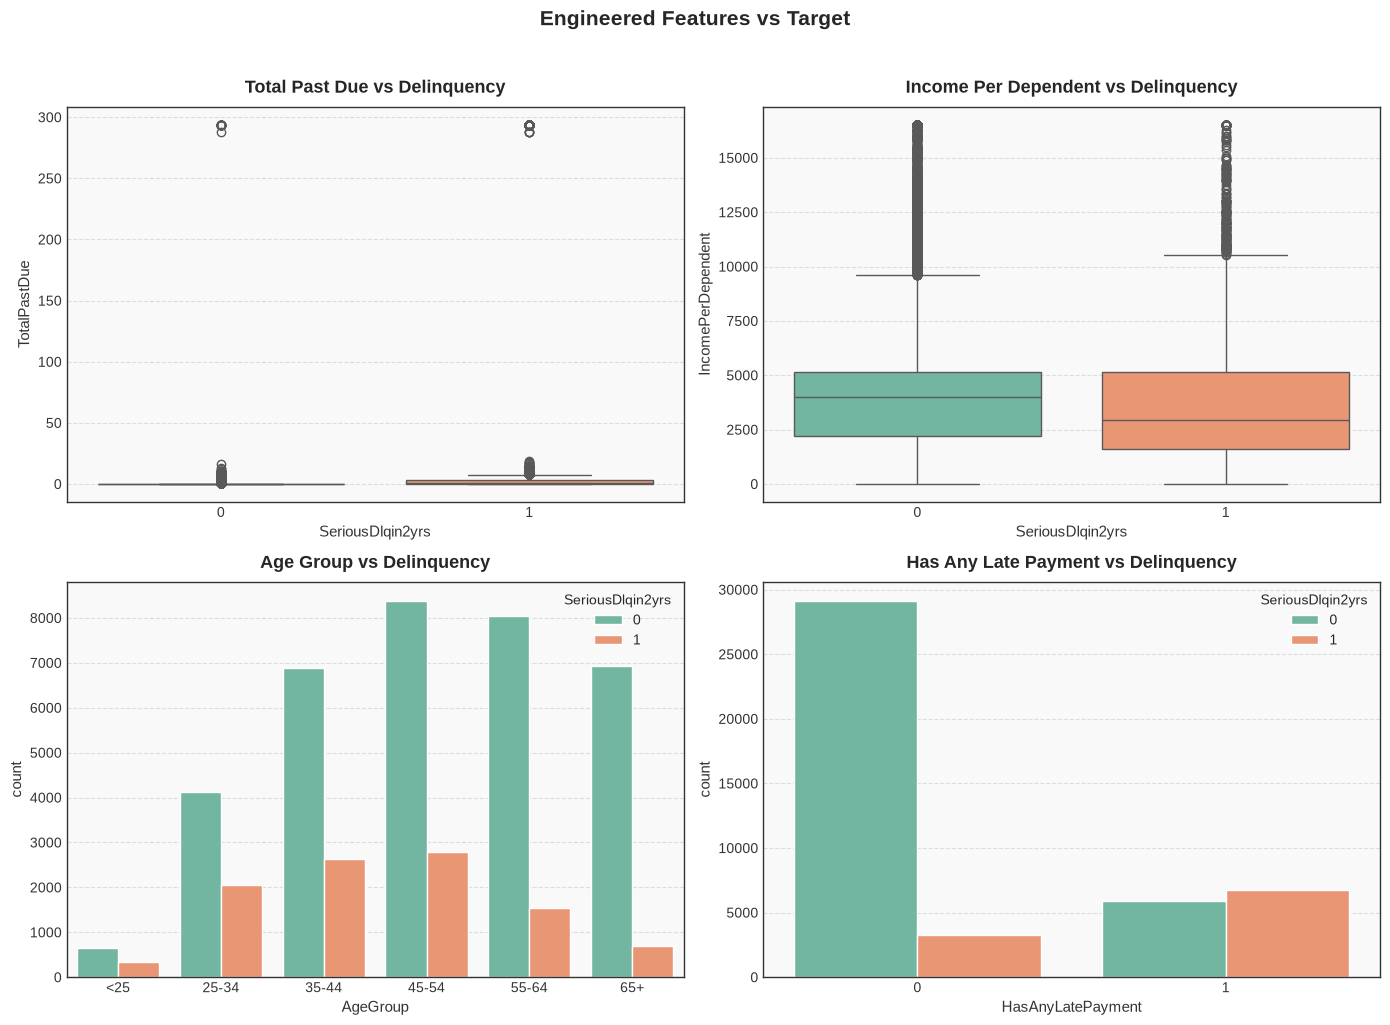

In [18]:
plot_2x2(
    plot_funcs=[
        lambda ax: sns.boxplot(x="SeriousDlqin2yrs", y="TotalPastDue", data=df, ax=ax, palette="Set2"),
        lambda ax: sns.boxplot(x="SeriousDlqin2yrs", y="IncomePerDependent", data=df, ax=ax, palette="Set2"),
        lambda ax: sns.countplot(x="AgeGroup", hue="SeriousDlqin2yrs", data=df, ax=ax, palette="Set2"),
        lambda ax: sns.countplot(x="HasAnyLatePayment", hue="SeriousDlqin2yrs", data=df, ax=ax, palette="Set2"),
    ],
    titles=[
        "Total Past Due vs Delinquency",
        "Income Per Dependent vs Delinquency",
        "Age Group vs Delinquency",
        "Has Any Late Payment vs Delinquency"
    ],
    suptitle="Engineered Features vs Target",
    save_path="../reports/figures/feature_engineering_overview.png"
)

In [19]:
df = pd.get_dummies(df, columns=["AgeGroup"], drop_first=True)
df.head()

,SeriousDlqin2yrs,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,MonthlyIncome,NumberOfDependents,DebtRatio_Flag,TotalPastDue,IncomePerDependent,HighDebtRatio,DebtRatio_log,HasAnyLatePayment,AgeGroup_25-34,AgeGroup_35-44,AgeGroup_45-54,AgeGroup_55-64,AgeGroup_65+
0,0,64,0,0.249908,0,0,8158.0,0,0,0,8158.0,0,0.223070,0,False,False,False,True,False
1,0,58,0,3496.000000,0,0,5166.0,0,1,0,5166.0,1,8.159661,0,False,False,False,True,False
2,0,41,0,0.456127,0,0,6666.0,0,0,0,6666.0,1,0.375780,0,False,True,False,False,False
3,0,43,0,0.000190,0,0,10500.0,2,0,0,3500.0,0,0.000190,0,False,True,False,False,False
4,1,49,0,0.271820,0,0,400.0,0,0,0,400.0,0,0.240449,0,False,False,True,False,False


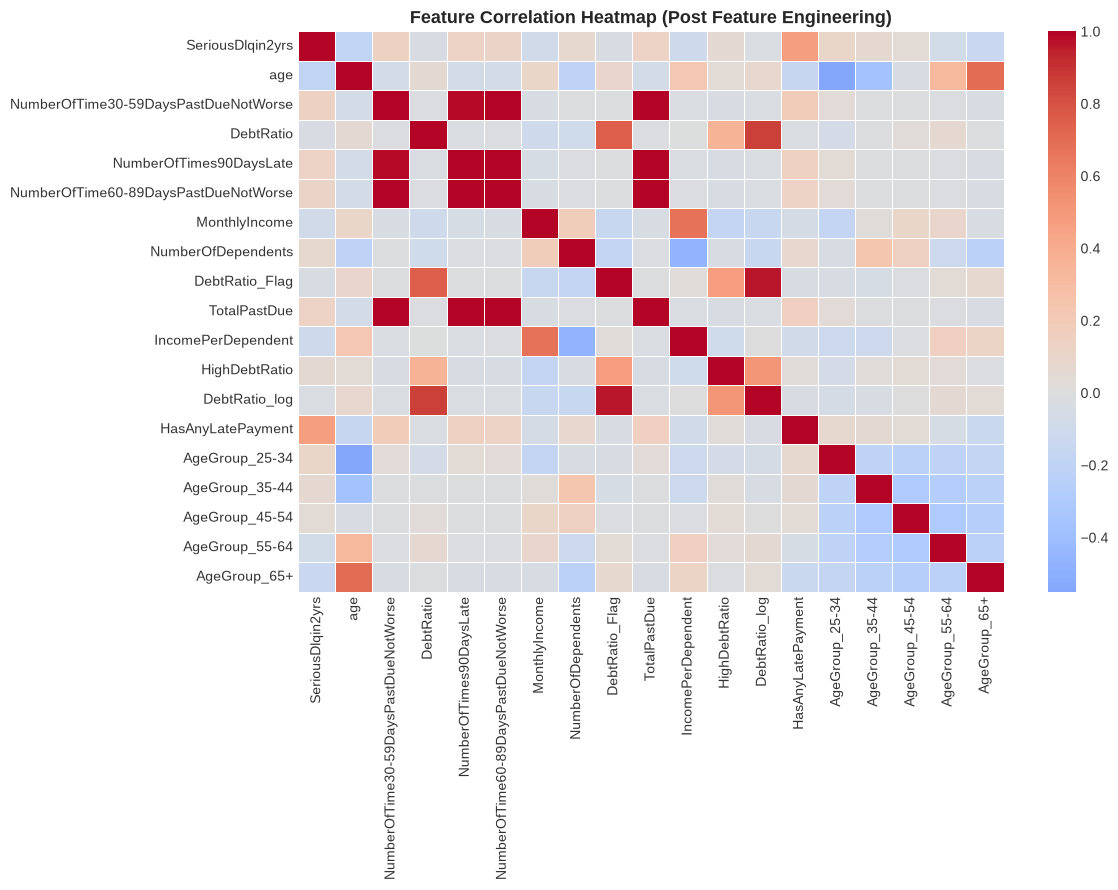

In [20]:
plt.figure(figsize=(12, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Correlation Heatmap (Post Feature Engineering)")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
target_corr = corr["SeriousDlqin2yrs"].sort_values(ascending=False)
target_corr

SeriousDlqin2yrs                        1.000000
HasAnyLatePayment                       0.468756
NumberOfTime30-59DaysPastDueNotWorse    0.141638
NumberOfTimes90DaysLate                 0.131774
TotalPastDue                            0.129893
NumberOfTime60-89DaysPastDueNotWorse    0.114938
AgeGroup_25-34                          0.105246
NumberOfDependents                      0.076769
AgeGroup_35-44                          0.067155
HighDebtRatio                           0.058489
AgeGroup_45-54                          0.037113
DebtRatio_log                          -0.029141
DebtRatio                              -0.034359
DebtRatio_Flag                         -0.036588
AgeGroup_55-64                         -0.078379
MonthlyIncome                          -0.086081
IncomePerDependent                     -0.106144
AgeGroup_65+                           -0.143368
age                                    -0.192937
Name: SeriousDlqin2yrs, dtype: float64

In [22]:
X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(36050, 18) (9013, 18)


In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

Logistic Regression Results
Accuracy: 0.789748141573283
Precision: 0.5215179968701096
Recall: 0.6648379052369078
F1: 0.5845209383907038
ROC-AUC: 0.8085802545576698


In [25]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight="balanced", random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest Results
Accuracy: 0.7986242094752025
Precision: 0.538
Recall: 0.6708229426433915
F1: 0.5971143174250833
ROC-AUC: 0.8304353983762055


In [26]:
import joblib

model_dir = "/run/media/awongo-fahadi-rashid/AFRAH/Projects/Recess Term/Finance/models"

joblib.dump(log_reg, f"{model_dir}/logistic_regression_model.pkl")
joblib.dump(rf, f"{model_dir}/random_forest_model.pkl")
joblib.dump(scaler, f"{model_dir}/scaler.pkl")

print("Models saved successfully to:", model_dir)

Models saved successfully to: /run/media/awongo-fahadi-rashid/AFRAH/Projects/Recess Term/Finance/models


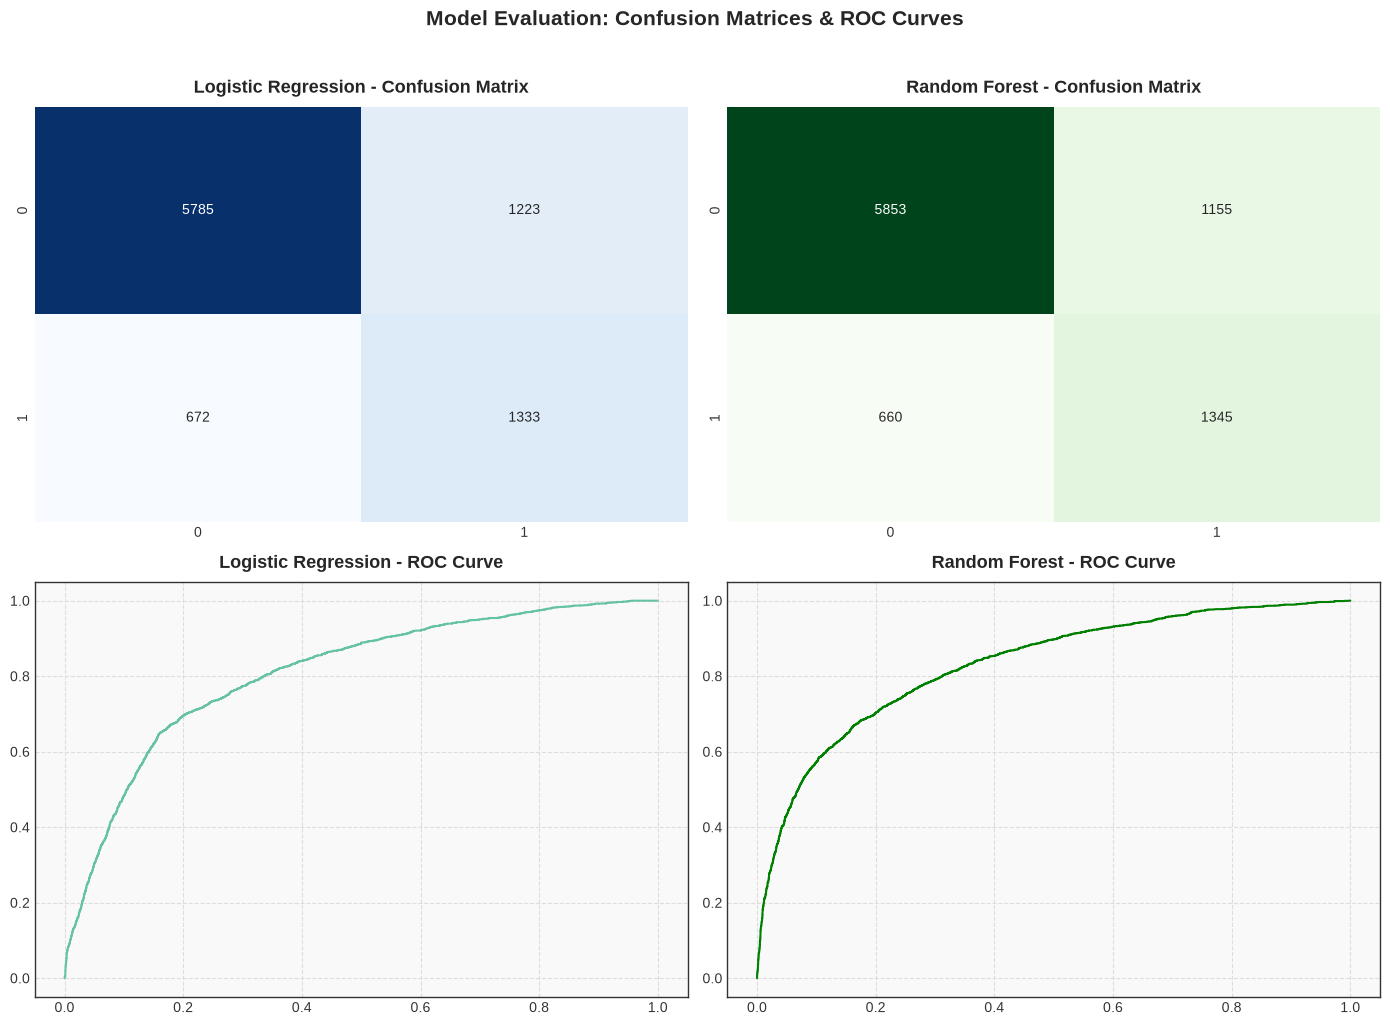

In [27]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plot_2x2(
    plot_funcs=[
        lambda ax: sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False),
        lambda ax: sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=ax, cbar=False),
        lambda ax: ax.plot(*roc_curve(y_test, y_proba_lr)[:2], label=f"AUC={roc_auc_score(y_test, y_proba_lr):.3f}") or ax.plot([0,1],[0,1],"k--") or ax.legend(),
        lambda ax: ax.plot(*roc_curve(y_test, y_proba_rf)[:2], label=f"AUC={roc_auc_score(y_test, y_proba_rf):.3f}", color="green") or ax.plot([0,1],[0,1],"k--") or ax.legend(),
    ],
    titles=[
        "Logistic Regression - Confusion Matrix",
        "Random Forest - Confusion Matrix",
        "Logistic Regression - ROC Curve",
        "Random Forest - ROC Curve"
    ],
    suptitle="Model Evaluation: Confusion Matrices & ROC Curves",
    save_path="../reports/figures/model_evaluation_overview.png"
)

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring="roc_auc")
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc")

print("Logistic Regression CV ROC-AUC scores:", lr_cv_scores)
print("Mean:", lr_cv_scores.mean(), "Std:", lr_cv_scores.std())

print("\nRandom Forest CV ROC-AUC scores:", rf_cv_scores)
print("Mean:", rf_cv_scores.mean(), "Std:", rf_cv_scores.std())

Logistic Regression CV ROC-AUC scores: [0.81828207 0.80329479 0.81671813 0.81478508 0.81592431]
Mean: 0.8138008747937423 Std: 0.005374885884417775

Random Forest CV ROC-AUC scores: [0.84016602 0.82441106 0.83743076 0.83435704 0.83965696]
Mean: 0.8352043662807089 Std: 0.005772589152936975


/tmp/ipykernel_138502/3770726716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values[:10], y=importances.index[:10], palette="viridis")


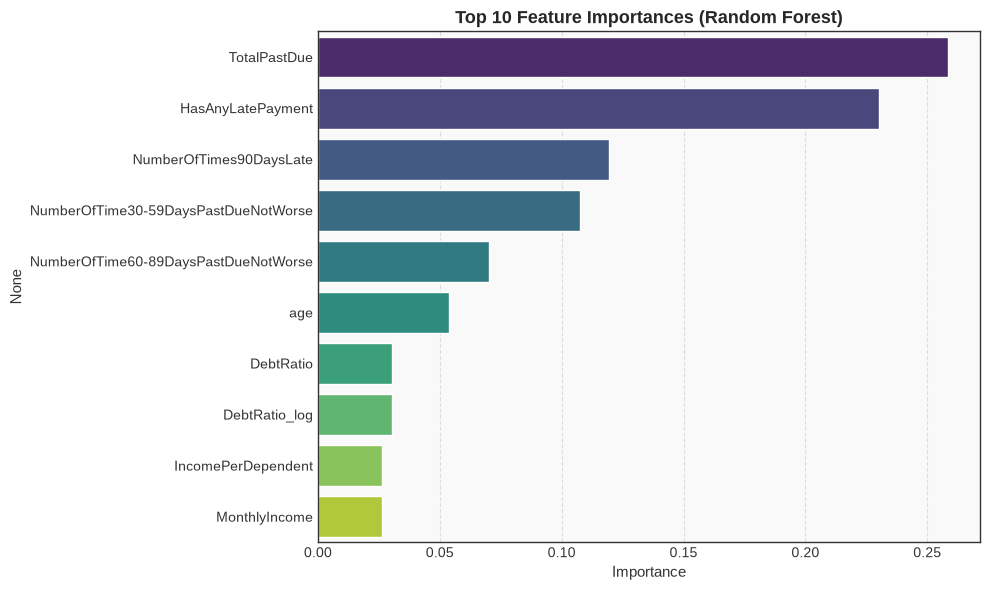

In [29]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values[:10], y=importances.index[:10], palette="viridis")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.90      0.83      0.86      7008
           1       0.52      0.66      0.58      2005

    accuracy                           0.79      9013
   macro avg       0.71      0.75      0.72      9013
weighted avg       0.81      0.79      0.80      9013

Random Forest:
               precision    recall  f1-score   support

           0       0.90      0.84      0.87      7008
           1       0.54      0.67      0.60      2005

    accuracy                           0.80      9013
   macro avg       0.72      0.75      0.73      9013
weighted avg       0.82      0.80      0.81      9013



In [31]:
import joblib

model_dir = "/run/media/awongo-fahadi-rashid/AFRAH/Projects/Recess Term/Finance/models"

rf_loaded = joblib.load(f"{model_dir}/random_forest_model.pkl")
print("Model loaded successfully")

Model loaded successfully


In [32]:
def predict_credit_risk(applicant_dict, model, feature_columns):
    """
    applicant_dict: dict with raw applicant values
    model: trained model (e.g. rf_loaded)
    feature_columns: X.columns from training (to match order/format exactly)
    """
    # Convert to a single-row dataframe
    input_df = pd.DataFrame([applicant_dict])

    # Ensure all expected columns exist (missing ones filled with 0, e.g. AgeGroup dummies)
    for col in feature_columns:
        if col not in input_df.columns:
            input_df[col] = 0

    # Reorder columns to match training exactly
    input_df = input_df[feature_columns]

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    return prediction, probability

In [33]:
new_applicant = {
    "age": 35,
    "NumberOfTime30-59DaysPastDueNotWorse": 1,
    "DebtRatio": 0.45,
    "NumberOfTimes90DaysLate": 0,
    "NumberOfTime60-89DaysPastDueNotWorse": 0,
    "MonthlyIncome": 4500,
    "NumberOfDependents": 2,
    "DebtRatio_Flag": 0,
    "DebtRatio_log": np.log1p(0.45),
    "TotalPastDue": 1,
    "IncomePerDependent": 4500 / 3,
    "HighDebtRatio": 0,
    "HasAnyLatePayment": 1,
    "AgeGroup_25-34": 0,
    "AgeGroup_35-44": 1,
    "AgeGroup_45-54": 0,
    "AgeGroup_55-64": 0,
    "AgeGroup_65+": 0,
}

pred, prob = predict_credit_risk(new_applicant, rf_loaded, X.columns)

print(f"Prediction: {'High Risk (Likely Delinquent)' if pred == 1 else 'Low Risk'}")
print(f"Probability of delinquency: {prob:.2%}")

Prediction: High Risk (Likely Delinquent)
Probability of delinquency: 67.71%


In [34]:
import joblib
import os

app_model_dir = "../app/model"
os.makedirs(app_model_dir, exist_ok=True)

joblib.dump(rf, f"{app_model_dir}/random_forest_model.pkl")
joblib.dump(list(X.columns), f"{app_model_dir}/feature_columns.pkl")

print("Model and feature columns exported for Flask app")

Model and feature columns exported for Flask app
